## Load dataset

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import functions as F
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
from pyspark.ml.clustering import KMeans

In [2]:
spark = SparkSession.builder.appName("FlightProject").getOrCreate()

df = spark.read.parquet("/Users/huynhphuongchi/Desktop/Unipi/Distributed data Analysis and Mining/flights_cleaned.parquet")
df.createOrReplaceTempView("flight_cleaned")

df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 21:07:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- Hour: long (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DELAYED: integer (nullable = true)
 |-- ROUTE: string (nullable = true)
 |-- AIRPORT_DELAY_RATE: double (nullable = true)
 |-- ROUTE_DELAY_RATE: double (nullable = true)
 |-- AIRLINE_DELAY_RATE: double (nullable = true)



In [3]:
df.show()

+---------+--------+-------+---------+----------------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+
|DEP_DELAY|TAXI_OUT|TAXI_IN|ARR_DELAY|CRS_ELAPSED_TIME|DISTANCE|Hour|DayOfWeek|Month|DELAYED|  ROUTE| AIRPORT_DELAY_RATE|   ROUTE_DELAY_RATE| AIRLINE_DELAY_RATE|
+---------+--------+-------+---------+----------------+--------+----+---------+-----+-------+-------+-------------------+-------------------+-------------------+
|     25.0|    13.0|   16.0|      7.0|           114.0|   378.0|  17|        5|    1|      1|BGM_DTW|0.19148936170212766|0.15447154471544716|0.14978180536858177|
|    -10.0|     9.0|    9.0|    -22.0|           101.0|   378.0|  12|        2|    1|      0|BGM_DTW|0.19148936170212766|0.15447154471544716|0.12137536761674408|
|     -4.0|    25.0|    8.0|    -13.0|           110.0|   378.0|  12|        1|   12|      0|BGM_DTW|0.19148936170212766|0.15447154471544716|0.14978180536858177|
|      0.0|    23.0|    9.0|

In [4]:
num_cores = spark.sparkContext.defaultParallelism
print(f"Spark is using {num_cores} cores.")

Spark is using 10 cores.


In [5]:
df.rdd.getNumPartitions()

10

In [6]:
df_cluster = df.repartition(32)

In [7]:
spark.conf.set("spark.sql.shuffle.partitions", 32)

In [8]:
df_cluster.cache()
df_cluster.count()

1931907

# Pre-processing

In [ ]:
route_features = df_cluster.groupBy("ROUTE").agg(
    F.count("*").alias("total_flights"),
    
    F.avg("DEP_DELAY").alias("avg_dep_delay"),
    F.avg("ARR_DELAY").alias("avg_arr_delay"),
    
    F.avg("TAXI_OUT").alias("avg_taxi_out"),
    F.avg("TAXI_IN").alias("avg_taxi_in"),
    
    F.avg("DISTANCE").alias("distance"),
    
    F.avg("AIRPORT_DELAY_RATE").alias("airport_delay_rate"),
    F.avg("ROUTE_DELAY_RATE").alias("route_delay_rate"),
    
    F.sum(F.when(F.col("DEP_DELAY")>0,1).otherwise(0)).alias("delayed_flights"))

In [ ]:
route_features = route_features.withColumn(
    "delay_rate",
    F.col("delayed_flights") / F.col("total_flights"))

In [ ]:
features = [
    "avg_dep_delay",
    "avg_arr_delay",
    "delay_rate",
    "avg_taxi_out",
    "avg_taxi_in",
    "distance",
    "airport_delay_rate",
    "route_delay_rate"]

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features")

df_cluster = assembler.transform(route_features)

In [12]:
df_cluster.show()

+-------+-------------+------------------+-------------------+------------------+------------------+--------+-------------------+-------------------+---------------+-------------------+--------------------+
|  ROUTE|total_flights|     avg_dep_delay|      avg_arr_delay|      avg_taxi_out|       avg_taxi_in|distance| airport_delay_rate|   route_delay_rate|delayed_flights|         delay_rate|            features|
+-------+-------------+------------------+-------------------+------------------+------------------+--------+-------------------+-------------------+---------------+-------------------+--------------------+
|EWR_CLT|         1103| 9.380779691749773| 2.0462375339981866| 21.84768812330009| 9.236627379873074|   529.0|0.23043622042509695| 0.1958295557570262|            360| 0.3263825929283772|[9.38077969174977...|
|OAK_PHX|          736| 6.804347826086956|0.09918478260869565| 11.69836956521739| 6.324728260869565|   646.0|0.19024577572964665|0.13451086956521732|            299|       

In [13]:
'''
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features"
)

scaler_model = scaler.fit(df_cluster)
df_cluster= scaler_model.transform(df_cluster)
'''

'\nscaler = StandardScaler(\n    inputCol="features",\n    outputCol="scaled_features"\n)\n\nscaler_model = scaler.fit(df_cluster)\ndf_cluster= scaler_model.transform(df_cluster)\n'

In [14]:
df_cluster.show()

+-------+-------------+------------------+-------------------+------------------+------------------+--------+-------------------+-------------------+---------------+-------------------+--------------------+
|  ROUTE|total_flights|     avg_dep_delay|      avg_arr_delay|      avg_taxi_out|       avg_taxi_in|distance| airport_delay_rate|   route_delay_rate|delayed_flights|         delay_rate|            features|
+-------+-------------+------------------+-------------------+------------------+------------------+--------+-------------------+-------------------+---------------+-------------------+--------------------+
|EWR_CLT|         1103| 9.380779691749773| 2.0462375339981866| 21.84768812330009| 9.236627379873074|   529.0|0.23043622042509695| 0.1958295557570262|            360| 0.3263825929283772|[9.38077969174977...|
|OAK_PHX|          736| 6.804347826086956|0.09918478260869565| 11.69836956521739| 6.324728260869565|   646.0|0.19024577572964665|0.13451086956521732|            299|       

# Elbow

In [15]:
wssse = {}
silhouette = {}
centers = {}

k_values = range(2, 21)

for k in k_values:

    kmeans = KMeans(
        featuresCol="features",
        k=k)

    model = kmeans.fit(df_cluster)

    # WSSSE
    summary = model.summary
    wssse[k] = summary.trainingCost

    # Predictions
    predictions = model.transform(df_cluster)

    # Silhouette score
    evaluator = ClusteringEvaluator(featuresCol="features")
    silhouette[k] = evaluator.evaluate(predictions)

    # Cluster centers
    centers[k] = model.clusterCenters()

    print(f"k = {k}, WSSSE = {wssse[k]}, Silhouette = {silhouette[k]}")

26/03/16 21:08:09 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k = 2, WSSSE = 886647950.3933299, Silhouette = 0.7880729496228206
k = 3, WSSSE = 395990704.9866334, Silhouette = 0.7341375012425635
k = 4, WSSSE = 236115018.87968433, Silhouette = 0.7135698460088575
k = 5, WSSSE = 145290173.07297787, Silhouette = 0.7115796769773491
k = 6, WSSSE = 108425252.3172206, Silhouette = 0.7027369794502548
k = 7, WSSSE = 76918942.89804988, Silhouette = 0.6988227544844869
k = 8, WSSSE = 60419868.66140618, Silhouette = 0.6912881900737402
k = 9, WSSSE = 49623805.816198915, Silhouette = 0.6826521198952101
k = 10, WSSSE = 43978971.20548145, Silhouette = 0.6888009622899058
k = 11, WSSSE = 35904602.83387955, Silhouette = 0.6696388014289669
k = 12, WSSSE = 31840279.036375064, Silhouette = 0.6636776130877945
k = 13, WSSSE = 26032899.9321421, Silhouette = 0.665139458251681
k = 14, WSSSE = 23392734.66300597, Silhouette = 0.6517095703737039
k = 15, WSSSE = 21820166.70466452, Silhouette = 0.657302259551087
k = 16, WSSSE = 18410680.742604632, Silhouette = 0.6564386324201443
k

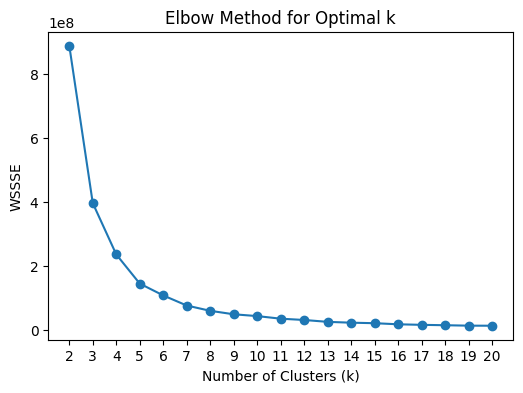

In [16]:
plt.figure(figsize=(6,4))

plt.plot(
    list(wssse.keys()),
    list(wssse.values()),
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WSSSE")
plt.title("Elbow Method for Optimal k")

plt.xticks(list(wssse.keys()))

plt.show()

# K-Means

In [ ]:
kmeans = KMeans(k=3, featuresCol="features", seed=42, maxIter=50, initSteps=10)

model = kmeans.fit(df_cluster)

clusters = model.transform(df_cluster)

In [ ]:
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction")

silhouette = evaluator.evaluate(clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.7341375012425635


In [19]:
clusters.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1| 2990|
|         0| 3630|
|         2| 1015|
+----------+-----+



In [20]:
centers = model.clusterCenters()

for i, c in enumerate(centers):
    print(f"Cluster {i}: {c}")

Cluster 0: [8.44198919e+00 3.67263850e+00 2.99870664e-01 1.58623825e+01
 6.96677699e+00 4.34901006e+02 1.66076691e-01 1.75562061e-01]
Cluster 1: [1.03397155e+01 5.23622266e+00 3.63627386e-01 1.53050257e+01
 7.34641055e+00 1.05361155e+03 1.78866205e-01 2.04886018e-01]
Cluster 2: [1.07806600e+01 2.86109789e+00 4.15136151e-01 1.66804238e+01
 7.69653011e+00 2.04662446e+03 1.72834197e-01 2.00106986e-01]


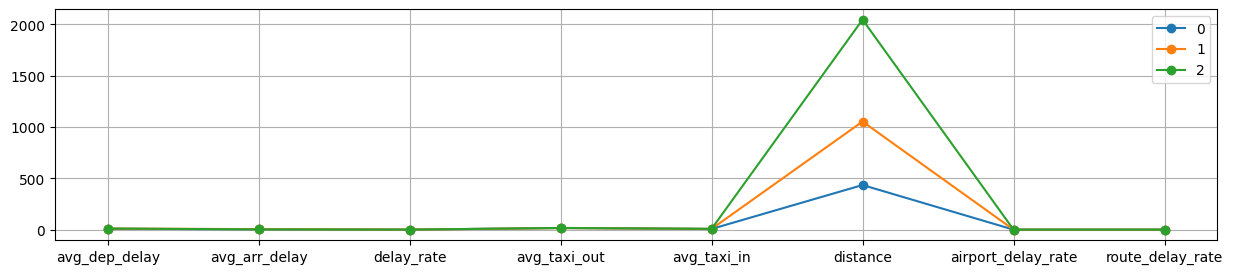

In [35]:
centers_df = pd.DataFrame(centers, columns=features)

centers_df.T.plot(figsize=(15,3), marker='o')

plt.grid()
plt.show()

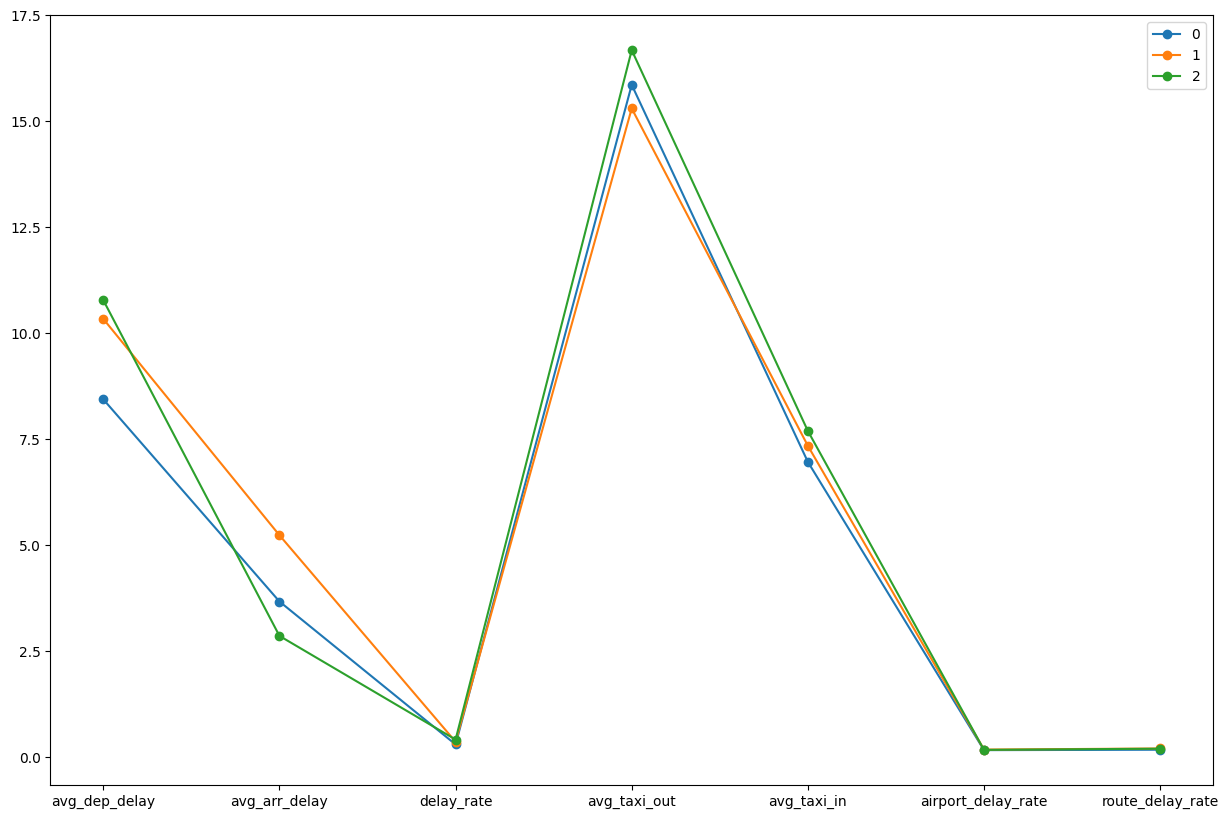

In [32]:
centers_df = pd.DataFrame(centers, columns=features).drop(columns=["distance"])

centers_df.T.plot(figsize=(15,10), marker='o')

plt.show()

# PCA map

In [22]:
from pyspark.ml.feature import PCA
pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(clusters)
pca_df = pca_model.transform(clusters)

26/03/16 21:09:00 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array

pca_points = pca_df.select(
    col("prediction"),
    vector_to_array("pcaFeatures")[0].alias("PC1"),
    vector_to_array("pcaFeatures")[1].alias("PC2"))

In [24]:
pca_pd = pca_points.toPandas()

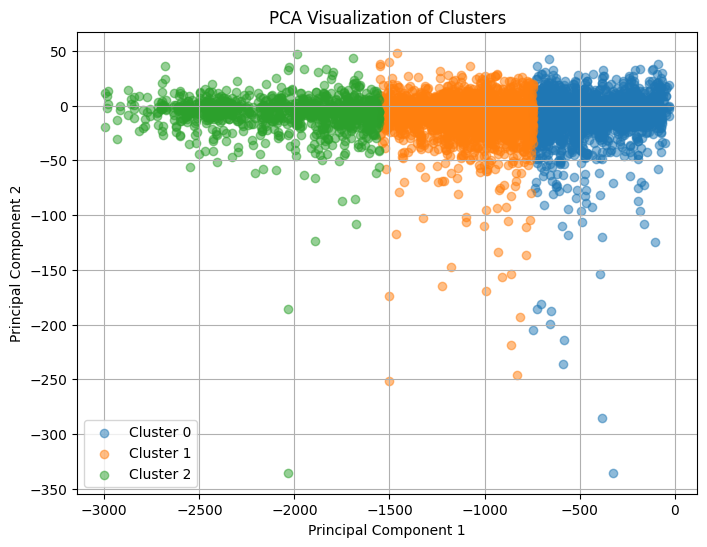

In [ ]:
plt.figure(figsize=(8,6))

for cluster in sorted(pca_pd["prediction"].unique()):
    
    subset = pca_pd[pca_pd["prediction"] == cluster]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization of Clusters")

plt.legend()
plt.grid()

plt.show()